# BTS DB1B

## Import and Configuration

In [1]:
import sys
import os

# Check Python version
print(f"Python Version: `{sys.version}`")  # Detailed version info
print(f"Base Python location: `{sys.base_prefix}`")
print(f"Current Environment location: `{os.path.basename(sys.prefix)}`", end='\n\n')

Python Version: `3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]`
Base Python location: `C:\Users\LMT\AppData\Local\Programs\Python\Python312`
Current Environment location: `.venv`



In [2]:
sys.path.append("../src") if "../src" not in sys.path else None

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

from sklearn.linear_model import LinearRegression

import pyarrow.parquet as pq
from pathlib import Path
import logging

import data_handler

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)

## Data Management with `BTSDataHandler`

In [4]:
handler = data_handler.BTSDataHandler(base_dir=Path("data/bts"))

### Download CSVs from BTS website (separate subtask)

In [5]:
# # Download all quarters already identified in the project (2024 Q1 - 2025 Q2)
# results = handler.download_range(
#     start=data_handler.Quarter(2024, 1),
#     end=data_handler.Quarter(2025, 2),
# )

# # Check what's available locally
# inventory = handler.list_available_quarters()
# for stage, quarters in inventory.items():
#     print(f"{stage}: {[str(q) for q in quarters]}")


In [6]:
# Free disk space after Parquet conversion (separate subtask)
handler.cleanup_zips()


0

### Convert CSVs to Parquet and verify integrity

In [7]:
# # Convert all downloaded quarters
# results = handler.convert_range_to_parquet(
#     start=data_handler.Quarter(2024, 1),
#     end=data_handler.Quarter(2025, 2),
#     delete_csv=False,  # keep CSVs until verified
# )

In [8]:
# Once verified, delete CSVs to reclaim ~9 GB of disk space
# handler.cleanup_csvs()

### Batch processing test

How Batch Processing Fits the Pipeline

```
                    24 GB RAM Boundary
                    ─────────────────────
                    │                   │
  Parquet Files     │   iter_quarters   │    Output
  ─────────────     │   ─────────────   │    ──────
  2024_Q1.parquet ──┤                   ├──> Aggregates
  2024_Q2.parquet ──┤  One quarter at   ├──> Samples
  2024_Q3.parquet ──┤  a time in RAM    ├──> Route extracts
  2024_Q4.parquet ──┤                   ├──> Feature tables
  2025_Q1.parquet ──┤  ~800 MB each     │
  2025_Q2.parquet ──┤                   │
                    │                   │
                    ─────────────────────
```

The `iter_quarters` generator is the foundation -- `batch_aggregate`, `get_route_data`, and `create_sample` all delegate to it. This guarantees that multi-quarter operations never exceed one quarter of memory at a time (~800 MB per quarter with all columns, much less with column selection).

In [9]:
# q1 = data_handler.Quarter(2024, 1)

# # 1. Check memory estimate before loading
# est = handler.memory_estimate(q1)
# for k, v in est.items():
#     print(f"  {k}: {v}")

# # 2. Create a 10% sample for fast local iteration
# sample_path = handler.create_sample(q1, q1, fraction=0.1)

# # 3. Load sample with specific columns for exploration
# df = handler.load_sample(columns=[
#     "Origin", "Dest", "MktFare", "MktDistance",
#     "RPCarrier", "Passengers", "MktCoupons",
#     "Year", "Quarter",
# ])

# # 4. Quick sanity checks
# print(f"\nShape: {df.shape}")
# print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
# print(f"\nMktFare stats:")
# print(df["MktFare"].describe())
# print(f"\nTop 10 routes:")
# print(
#     df.groupby(["Origin", "Dest"])["MktFare"]
#     .agg(["mean", "count"])
#     .sort_values("count", ascending=False)
#     .head(10)
# )
# print(f"\nCarriers: {df['RPCarrier'].nunique()}")
# print(f"Airports (origin): {df['Origin'].nunique()}")

# # 5. Route-specific extraction (useful for later comparison with UK routes)
# hub_data = handler.get_route_data(
#     q1, q1,
#     origins=["JFK", "LAX", "ORD", "ATL", "DFW"],
#     columns=[
#         "Origin", "Dest", "MktFare", "MktDistance",
#         "RPCarrier", "Passengers", "MktCoupons",
#     ],
# )
# print(f"\nMajor hub data: {len(hub_data)} rows")


### Existing Files Status View

In [10]:
# Check current state
status = handler.detect_pipeline_status(
    data_handler.Quarter(2024, 1),
    data_handler.Quarter(2025, 2),
)
handler.print_status(status)



Quarter         ZIP       CSV    Parquet   Valid         Rows Stage        Next Action
------------------------------------------------------------------------------------------
2024_Q1          --    1782MB      112MB     yes    7,403,594 parquet      process_features
2024_Q2          --    2055MB      129MB     yes    8,527,138 parquet      process_features
2024_Q3          --    1999MB      127MB     yes    8,290,377 parquet      process_features
2024_Q4          --    2051MB      129MB     yes    8,518,002 parquet      process_features
2025_Q1          --    1754MB      112MB     yes    7,290,528 parquet      process_features
2025_Q2          --    2035MB      130MB     yes    8,442,941 parquet      process_features

Summary: 6/6 quarters ready
  Total rows in Parquet: 48,472,580


### Full Pipeline Runner

In [11]:
final = handler.run_pipeline(
    data_handler.Quarter(2024, 1),
    data_handler.Quarter(2025, 2),
    delete_csv=False,  # keep until verified
    delete_zip=True,   # reclaim space immediately
)

2026-04-01 17:49:06,664 [INFO] Pipeline status before run:



Quarter         ZIP       CSV    Parquet   Valid         Rows Stage        Next Action
------------------------------------------------------------------------------------------
2024_Q1          --    1782MB      112MB     yes    7,403,594 parquet      process_features
2024_Q2          --    2055MB      129MB     yes    8,527,138 parquet      process_features
2024_Q3          --    1999MB      127MB     yes    8,290,377 parquet      process_features
2024_Q4          --    2051MB      129MB     yes    8,518,002 parquet      process_features
2025_Q1          --    1754MB      112MB     yes    7,290,528 parquet      process_features
2025_Q2          --    2035MB      130MB     yes    8,442,941 parquet      process_features

Summary: 6/6 quarters ready
  Total rows in Parquet: 48,472,580


Pipeline progress: 0quarter [00:00, ?quarter/s]
2026-04-01 17:49:06,705 [INFO] Pipeline status after run:



Quarter         ZIP       CSV    Parquet   Valid         Rows Stage        Next Action
------------------------------------------------------------------------------------------
2024_Q1          --    1782MB      112MB     yes    7,403,594 parquet      process_features
2024_Q2          --    2055MB      129MB     yes    8,527,138 parquet      process_features
2024_Q3          --    1999MB      127MB     yes    8,290,377 parquet      process_features
2024_Q4          --    2051MB      129MB     yes    8,518,002 parquet      process_features
2025_Q1          --    1754MB      112MB     yes    7,290,528 parquet      process_features
2025_Q2          --    2035MB      130MB     yes    8,442,941 parquet      process_features

Summary: 6/6 quarters ready
  Total rows in Parquet: 48,472,580

PIPELINE RUN REPORT
  Duration:           0.0 minutes
  Processed:          0
  Skipped:            6
  Failed:             0
  Downloaded:         0.0 MB
  Rows converted:     0
  Parquet on disk:    0.

### Create sample of 10% for testing downstream components

In [12]:
# sample_path = handler.create_sample(
#     data_handler.Quarter(2024, 1),
#     data_handler.Quarter(2025, 2),
#     fraction=0.1,
# )

## Data Exploration (EDA)

In [13]:
df = handler.load_sample()
df

2026-04-01 17:49:14,323 [INFO] Loaded sample: 4847258 rows x 30 cols (1008.8 MB)


,ItinID,MktID,MktCoupons,Year,Quarter,OriginAirportID,Origin,OriginCountry,OriginState,DestAirportID,...,OpCarrier,BulkFare,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,ItinGeoType,MktGeoType
0,202411970533,20241197053301,1,2024,1,11433,DTW,US,MI,13303,...,DL,0.0,4.0,373.0,1145.0,3,1145.0,1145.0,2,2
1,202412463889,20241246388902,1,2024,1,13487,MSP,US,MN,14635,...,DL,0.0,1.0,818.5,1416.0,3,1416.0,1416.0,2,2
2,202413353154,20241335315401,1,2024,1,14100,PHL,US,PA,12451,...,OH,0.0,1.0,605.5,742.0,2,742.0,742.0,2,2
3,202415072826,20241507282603,1,2024,1,10423,AUS,US,TX,11697,...,WN,0.0,1.0,288.0,1105.0,3,1105.0,1105.0,2,2
4,202411019257,20241101925703,2,2024,1,15027,STX,US,VI,14307,...,AA,0.0,1.0,7.5,2245.0,5,2245.0,1700.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4847253,202523190026,20252319002602,1,2025,2,11980,GRI,US,NE,10466,...,G4,0.0,7.0,21.0,905.0,2,905.0,905.0,2,2
4847254,202526935418,20252693541802,1,2025,2,12953,LGA,US,NY,15016,...,YX,0.0,1.0,284.0,888.0,2,888.0,888.0,2,2
4847255,202523603046,20252360304601,1,2025,2,10397,ATL,US,GA,11433,...,NK,0.0,5.0,65.0,594.0,2,594.0,594.0,2,2
4847256,202523838023,20252383802301,1,2025,2,11278,DCA,US,VA,15370,...,OH,0.0,1.0,363.0,1049.0,3,1049.0,1049.0,2,2


### Compute price distributions

In [14]:
# -- Configuration --------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
FARE_COL = "MktFare"

#### Overall Fare Summary Statistics

In [15]:
def fare_summary(series: pd.Series, name: str = "MktFare") -> pd.DataFrame:
    """Compute comprehensive summary statistics for a fare column."""
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    summary = {
        "count": len(series),
        "mean": series.mean(),
        "std": series.std(),
        "skewness": series.skew(),
        "kurtosis": series.kurtosis(),
        "min": series.min(),
    }
    for p in percentiles:
        summary[f"p{p}"] = series.quantile(p / 100)
    summary["max"] = series.max()
    summary["iqr"] = summary["p75"] - summary["p25"]
    summary["cv"] = series.std() / series.mean()  # coefficient of variation

    result = pd.DataFrame(
        {"statistic": summary.keys(), "value": summary.values()}
    )
    result["value"] = result["value"].map(
        lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"
    )
    return result


print("\n=== OVERALL FARE DISTRIBUTION ===")
print(fare_summary(df[FARE_COL]).to_string(index=False))



=== OVERALL FARE DISTRIBUTION ===
statistic        value
    count 4,847,258.00
     mean       271.79
      std       221.79
 skewness         6.81
 kurtosis       437.37
      min         0.11
       p1         5.00
       p5        25.50
      p10        79.50
      p25       148.72
      p50       231.00
      p75       340.47
      p90       481.00
      p95       614.52
      p99     1,090.00
      max    44,432.00
      iqr       191.75
       cv         0.82


#### Histogram with KDE and Log-Scale View

C:\Users\LMT\AppData\Local\Temp\ipykernel_11276\3438170012.py:53: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LMT\AppData\Local\Temp\ipykernel_11276\3438170012.py:53: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\ThongLai\Documents\Projects\Flight-Scanner\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ThongLai\Documents\Projects\Flight-Scanner\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


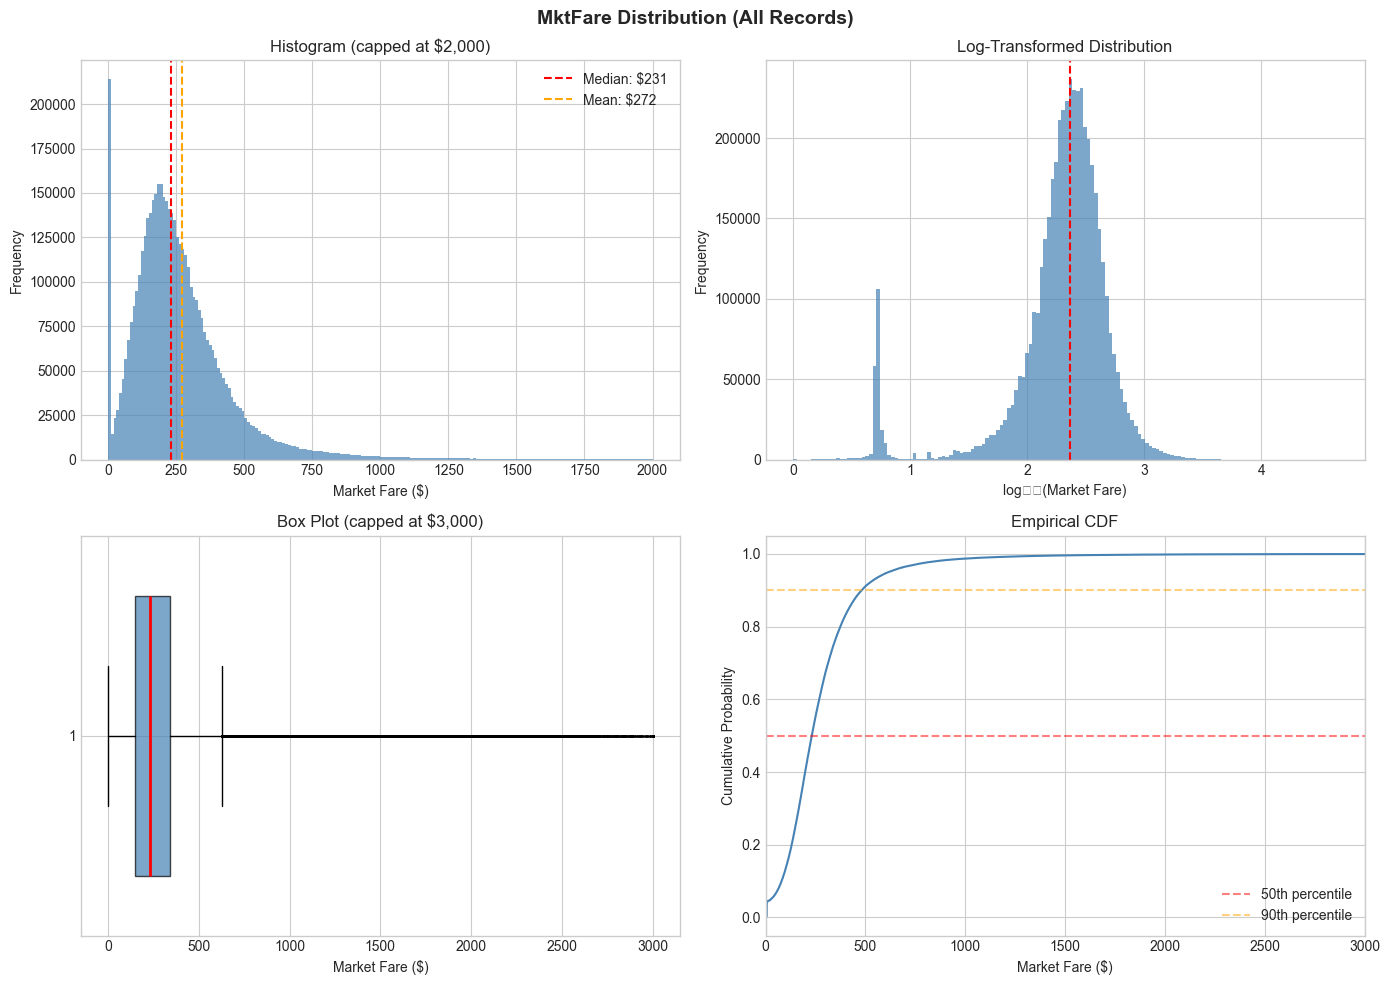

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MktFare Distribution (All Records)", fontsize=14, fontweight="bold")

# Raw histogram
ax = axes[0, 0]
ax.hist(df[FARE_COL], bins=200, range=(0, 2000), alpha=0.7,
        color="steelblue", edgecolor="none")
ax.set_xlabel("Market Fare ($)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram (capped at $2,000)")
ax.axvline(df[FARE_COL].median(), color="red", linestyle="--",
           label=f"Median: ${df[FARE_COL].median():.0f}")
ax.axvline(df[FARE_COL].mean(), color="orange", linestyle="--",
           label=f"Mean: ${df[FARE_COL].mean():.0f}")
ax.legend()

# Log-scale histogram
ax = axes[0, 1]
log_fares = np.log10(df[FARE_COL].clip(lower=1))
ax.hist(log_fares, bins=150, alpha=0.7, color="steelblue", edgecolor="none")
ax.set_xlabel("log₁₀(Market Fare)")
ax.set_ylabel("Frequency")
ax.set_title("Log-Transformed Distribution")
ax.axvline(np.log10(df[FARE_COL].median()), color="red", linestyle="--")

# Box plot
ax = axes[1, 0]
bp = ax.boxplot(
    df[FARE_COL].clip(upper=3000), vert=False, widths=0.7,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", markersize=1, alpha=0.3),
)
ax.set_xlabel("Market Fare ($)")
ax.set_title("Box Plot (capped at $3,000)")

# ECDF (empirical cumulative distribution)
ax = axes[1, 1]
sorted_fares = np.sort(df[FARE_COL].values)
ecdf = np.arange(1, len(sorted_fares) + 1) / len(sorted_fares)
# Downsample for plotting performance
step = max(1, len(sorted_fares) // 10000)
ax.plot(sorted_fares[::step], ecdf[::step], color="steelblue", linewidth=1.5)
ax.set_xlabel("Market Fare ($)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Empirical CDF")
ax.set_xlim(0, 3000)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="50th percentile")
ax.axhline(0.9, color="orange", linestyle="--", alpha=0.5, label="90th percentile")
ax.legend()

plt.tight_layout()
plt.show()


#### Distribution by Geography Type

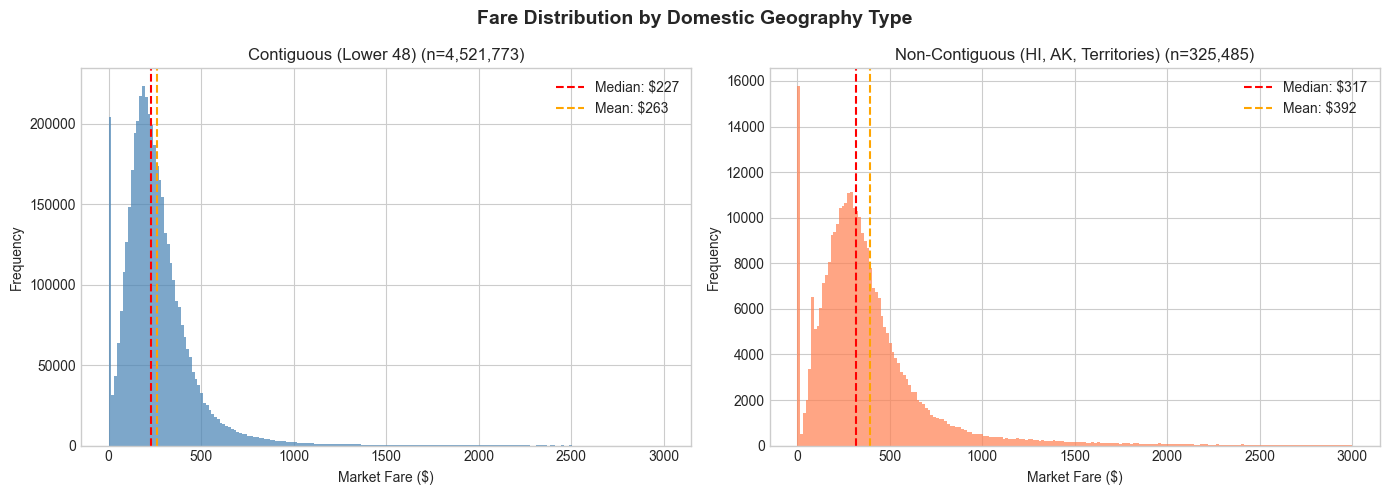


=== FARE BY GEOGRAPHY TYPE (CORRECTED) ===
                                        count    mean  median     std    p25    p75
GeoLabel                                                                           
Contiguous (Lower 48)                 4521773  263.14  226.52  206.01  147.0  332.0
Non-Contiguous (HI, AK, Territories)   325485  391.96  317.00  357.02  200.0  470.0


In [17]:
geo_labels = {
    1: "Non-Contiguous (HI, AK, Territories)",
    2: "Contiguous (Lower 48)",
}
df["GeoLabel"] = df["MktGeoType"].map(geo_labels).fillna("Other")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Fare Distribution by Domestic Geography Type",
    fontsize=14, fontweight="bold",
)

colors = {"Non-Contiguous (HI, AK, Territories)": "coral",
          "Contiguous (Lower 48)": "steelblue"}

for ax, (geo, group) in zip(axes, df.groupby("GeoLabel", observed=True)):
    ax.hist(group[FARE_COL], bins=200, range=(0, 3000),
            alpha=0.7, edgecolor="none", color=colors.get(geo, "gray"))
    ax.axvline(group[FARE_COL].median(), color="red", linestyle="--",
               label=f"Median: ${group[FARE_COL].median():.0f}")
    ax.axvline(group[FARE_COL].mean(), color="orange", linestyle="--",
               label=f"Mean: ${group[FARE_COL].mean():.0f}")
    ax.set_xlabel("Market Fare ($)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{geo} (n={len(group):,})")
    ax.legend()

plt.tight_layout()
plt.show()

print("\n=== FARE BY GEOGRAPHY TYPE (CORRECTED) ===")
geo_stats = df.groupby("GeoLabel", observed=True)[FARE_COL].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
).round(2)
print(geo_stats.to_string())

#### Distribution by Quarter (Temporal Trends)

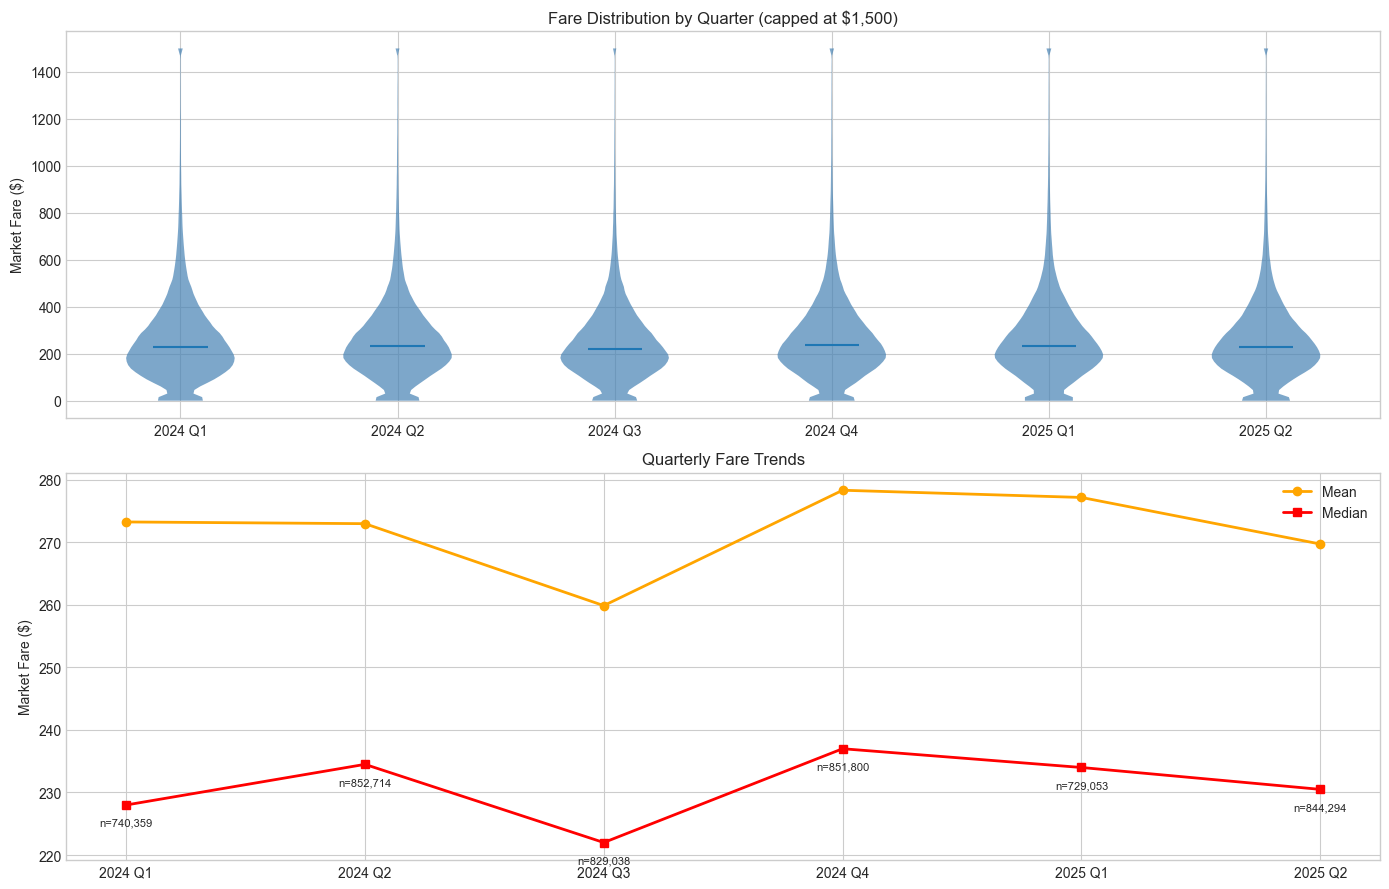

In [18]:
df["YearQuarter"] = df["Year"].astype(str) + " Q" + df["Quarter"].astype(str)
quarter_order = sorted(df["YearQuarter"].unique())

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Violin plot by quarter
ax = axes[0]
quarter_data = [
    df[df["YearQuarter"] == q][FARE_COL].clip(upper=1500).values
    for q in quarter_order
]
parts = ax.violinplot(quarter_data, showmedians=True, showextrema=False)
for body in parts["bodies"]:
    body.set_facecolor("steelblue")
    body.set_alpha(0.7)
ax.set_xticks(range(1, len(quarter_order) + 1))
ax.set_xticklabels(quarter_order)
ax.set_ylabel("Market Fare ($)")
ax.set_title("Fare Distribution by Quarter (capped at $1,500)")

# Median and mean trend
ax = axes[1]
quarterly_stats = df.groupby("YearQuarter", observed=True)[FARE_COL].agg(
    ["mean", "median", "count"]
).reindex(quarter_order)

ax.plot(quarter_order, quarterly_stats["mean"], "o-",
        color="orange", label="Mean", linewidth=2)
ax.plot(quarter_order, quarterly_stats["median"], "s-",
        color="red", label="Median", linewidth=2)
ax.set_ylabel("Market Fare ($)")
ax.set_title("Quarterly Fare Trends")
ax.legend()

# Annotate with counts
for i, q in enumerate(quarter_order):
    ax.annotate(
        f"n={quarterly_stats.loc[q, 'count']:,.0f}",
        (i, quarterly_stats.loc[q, "median"]),
        textcoords="offset points", xytext=(0, -15),
        fontsize=8, ha="center",
    )

plt.tight_layout()
plt.show()


#### Fare Per Mile Distribution (Computed Feature)

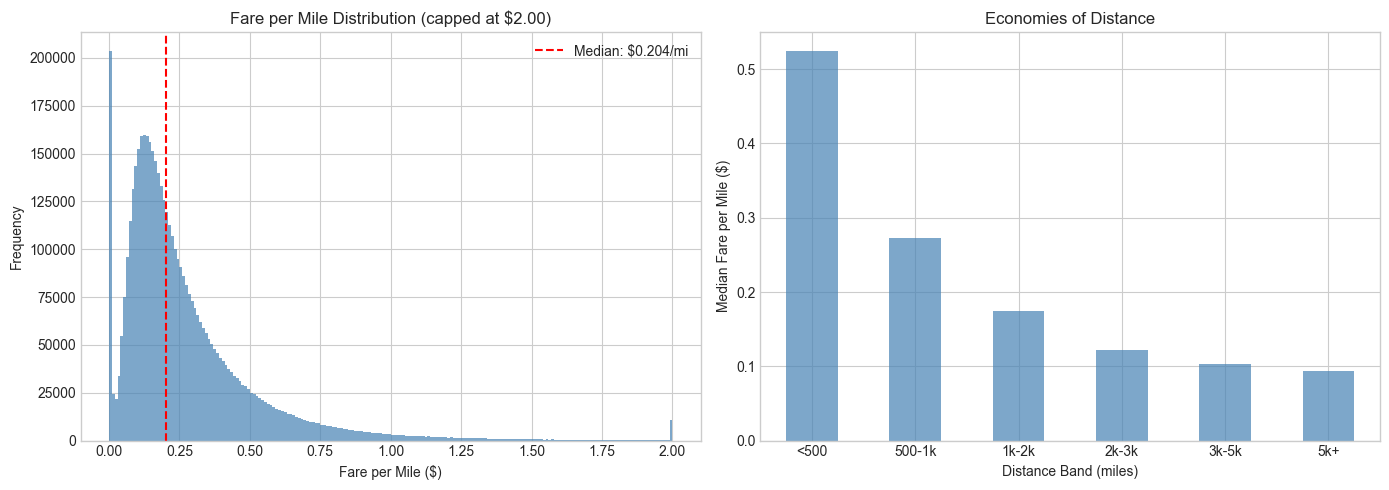


=== FARE PER MILE BY DISTANCE BAND ===
                count  median_fpm  mean_fpm  median_fare  mean_distance
DistanceBand                                                           
<500           616943      0.5241    0.6204       185.00       357.0497
500-1k        1503458      0.2721    0.3114       204.50       762.6673
1k-2k         1808831      0.1738    0.2018       240.50      1402.3116
2k-3k          787574      0.1217    0.1498       289.50      2388.9484
3k-5k          118533      0.1030    0.1261       398.71      3873.1606
5k+             11919      0.0942    0.1235       488.08      5402.3674


In [19]:
# Compute fare per mile -- a key normalised metric for transfer learning
df["FarePerMile"] = df[FARE_COL] / df["MktDistance"].clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall fare per mile
ax = axes[0]
fpm = df["FarePerMile"].clip(upper=2.0)
ax.hist(fpm, bins=200, alpha=0.7, color="steelblue", edgecolor="none")
ax.axvline(fpm.median(), color="red", linestyle="--",
           label=f"Median: ${fpm.median():.3f}/mi")
ax.set_xlabel("Fare per Mile ($)")
ax.set_ylabel("Frequency")
ax.set_title("Fare per Mile Distribution (capped at $2.00)")
ax.legend()

# Fare per mile by distance band
ax = axes[1]
distance_bins = [0, 500, 1000, 2000, 3000, 5000, 15000]
distance_labels = ["<500", "500-1k", "1k-2k", "2k-3k", "3k-5k", "5k+"]
df["DistanceBand"] = pd.cut(
    df["MktDistance"], bins=distance_bins, labels=distance_labels
)

fpm_by_dist = df.groupby("DistanceBand", observed=True)["FarePerMile"].median()
fpm_by_dist.plot.bar(ax=ax, color="steelblue", alpha=0.7)
ax.set_xlabel("Distance Band (miles)")
ax.set_ylabel("Median Fare per Mile ($)")
ax.set_title("Economies of Distance")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\n=== FARE PER MILE BY DISTANCE BAND ===")
fpm_stats = df.groupby("DistanceBand", observed=True).agg(
    count=("FarePerMile", "count"),
    median_fpm=("FarePerMile", "median"),
    mean_fpm=("FarePerMile", "mean"),
    median_fare=("MktFare", "median"),
    mean_distance=("MktDistance", "mean"),
).round(4)
print(fpm_stats.to_string())


#### Outlier Analysis

In [20]:
print("\n=== OUTLIER ANALYSIS ===")
thresholds = [
    ("< $10 (staff/error)", df[FARE_COL] < 10),
    ("$10-$50 (ultra-low)", df[FARE_COL].between(10, 50)),
    ("$50-$2000 (typical)", df[FARE_COL].between(50, 2000)),
    ("$2000-$5000 (premium)", df[FARE_COL].between(2000, 5000)),
    ("> $5000 (extreme)", df[FARE_COL] > 5000),
]

print(f"{'Segment':<30} {'Count':>10} {'Pct':>8} {'Median':>10}")
print("-" * 62)
for label, mask in thresholds:
    subset = df[mask]
    pct = 100 * len(subset) / len(df)
    median = subset[FARE_COL].median() if len(subset) > 0 else 0
    print(f"{label:<30} {len(subset):>10,} {pct:>7.2f}% ${median:>8,.0f}")

# What are the extreme fares?
print("\n=== TOP 20 HIGHEST FARES ===")
extreme = df.nlargest(20, FARE_COL)[
    ["Origin", "Dest", "MktFare", "MktDistance", "RPCarrier",
     "MktCoupons", "GeoLabel"]
]
print(extreme.to_string(index=False))

# BulkFare flag analysis
print("\n=== BULK FARE FLAG ===")
bulk_stats = df.groupby("BulkFare", observed=True)[FARE_COL].agg(
    ["count", "mean", "median"]
)
print(bulk_stats.round(2).to_string())



=== OUTLIER ANALYSIS ===
Segment                             Count      Pct     Median
--------------------------------------------------------------
< $10 (staff/error)               214,195    4.42% $       6
$10-$50 (ultra-low)               104,994    2.17% $      36
$50-$2000 (typical)             4,523,266   93.32% $     242
$2000-$5000 (premium)               6,750    0.14% $   2,355
> $5000 (extreme)                     135    0.00% $   7,726

=== TOP 20 HIGHEST FARES ===
Origin Dest  MktFare  MktDistance RPCarrier  MktCoupons              GeoLabel
   HIB  ORD  44432.0        508.0        OO           2 Contiguous (Lower 48)
   MIA  BNA  16790.0        978.0        AA           2 Contiguous (Lower 48)
   SLC  BOS  15994.0       2117.0        AA           2 Contiguous (Lower 48)
   MIA  ORD  15786.0       1249.0        AA           2 Contiguous (Lower 48)
   ATL  HPN  14841.0        781.0        OH           2 Contiguous (Lower 48)
   MIA  SLC  14789.0       2110.0        AA   

#### Direct vs Connecting Price Premium

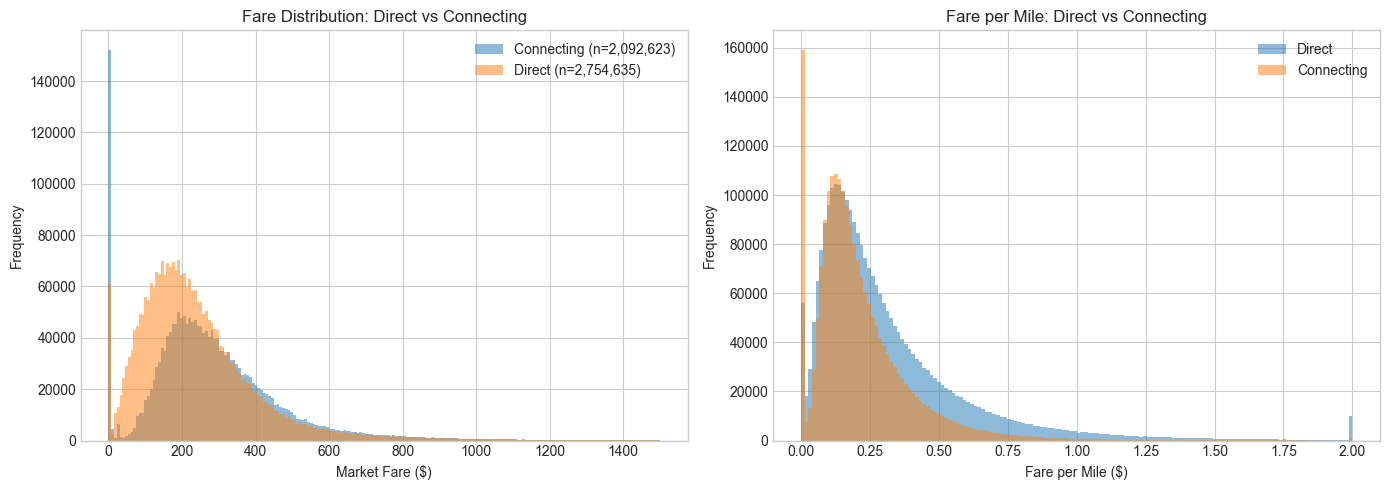


=== DIRECT vs CONNECTING ===
              count  mean_fare  median_fare  mean_fpm  median_distance
IsDirect                                                              
Connecting  2092623     298.64       260.84      0.22           1486.0
Direct      2754635     251.40       209.00      0.32            888.0


In [21]:
df["IsDirect"] = (df["MktCoupons"] == 1).map({True: "Direct", False: "Connecting"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlay
ax = axes[0]
for label, group in df.groupby("IsDirect", observed=True):
    ax.hist(group[FARE_COL], bins=200, range=(0, 1500),
            alpha=0.5, label=f"{label} (n={len(group):,})", edgecolor="none")
ax.set_xlabel("Market Fare ($)")
ax.set_ylabel("Frequency")
ax.set_title("Fare Distribution: Direct vs Connecting")
ax.legend()

# Fare per mile comparison
ax = axes[1]
direct_fpm = df[df["IsDirect"] == "Direct"]["FarePerMile"].clip(upper=2)
connecting_fpm = df[df["IsDirect"] == "Connecting"]["FarePerMile"].clip(upper=2)
ax.hist(direct_fpm, bins=150, alpha=0.5, label="Direct", edgecolor="none")
ax.hist(connecting_fpm, bins=150, alpha=0.5, label="Connecting", edgecolor="none")
ax.set_xlabel("Fare per Mile ($)")
ax.set_ylabel("Frequency")
ax.set_title("Fare per Mile: Direct vs Connecting")
ax.legend()

plt.tight_layout()
plt.show()

print("\n=== DIRECT vs CONNECTING ===")
print(
    df.groupby("IsDirect", observed=True)
    .agg(
        count=("MktFare", "count"),
        mean_fare=("MktFare", "mean"),
        median_fare=("MktFare", "median"),
        mean_fpm=("FarePerMile", "mean"),
        median_distance=("MktDistance", "median"),
    )
    .round(2)
    .to_string()
)


#### Routing Efficiency

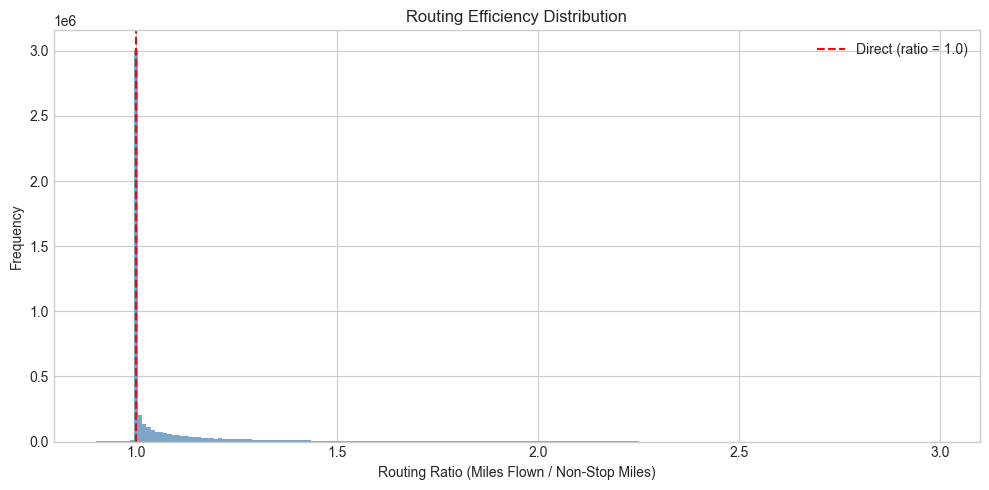

In [22]:
df["RoutingRatio"] = df["MktMilesFlown"] / df["NonStopMiles"].clip(lower=1)

fig, ax = plt.subplots(figsize=(10, 5))
routing = df[df["RoutingRatio"].between(0.9, 3.0)]
ax.hist(routing["RoutingRatio"], bins=200, alpha=0.7,
        color="steelblue", edgecolor="none")
ax.axvline(1.0, color="red", linestyle="--", label="Direct (ratio = 1.0)")
ax.set_xlabel("Routing Ratio (Miles Flown / Non-Stop Miles)")
ax.set_ylabel("Frequency")
ax.set_title("Routing Efficiency Distribution")
ax.legend()

plt.tight_layout()
plt.show()

### Identify top routes and carriers

In [23]:
# Computed features
df["FarePerMile"] = df["MktFare"] / df["MktDistance"].clip(lower=1)
df["IsDirect"] = (df["MktCoupons"] == 1)
df["Route"] = df["Origin"].astype(str) + "-" + df["Dest"].astype(str)

#### Competition Effect (Transferable)

In [24]:
significant_routes = (
    df.groupby("Route", observed=True)
    .agg(
        records=("MktFare", "count"),
        median_fare=("MktFare", "median"),
        carriers=("RPCarrier", "nunique"),
        mean_distance=("MktDistance", "mean"),
        mean_fpm=("FarePerMile", "mean"),
    )
    .query("records >= 100")
)

# Competition coefficient -- controls for distance
X = significant_routes[["carriers", "mean_distance"]].values
y = significant_routes["median_fare"].values

model = LinearRegression().fit(X, y)
print("=== COMPETITION EFFECT (controlling for distance) ===")
print(f"Each additional carrier: {model.coef_[0]:+.2f} on median fare")
print(f"Each additional mile:    {model.coef_[1]:+.4f} on median fare")
print(f"R-squared:               {model.score(X, y):.3f}")


=== COMPETITION EFFECT (controlling for distance) ===
Each additional carrier: +3.51 on median fare
Each additional mile:    +0.0516 on median fare
R-squared:               0.442


#### Carrier Pricing Tiers (Transferable)

In [25]:
carrier_fpm = (
    df.groupby("RPCarrier", observed=True)
    .agg(
        records=("MktFare", "count"),
        median_fpm=("FarePerMile", "median"),
        mean_distance=("MktDistance", "mean"),
    )
    .query("records >= 1000")
    .sort_values("median_fpm")
)

# Tier spread
print("=== CARRIER TIER SPREAD ===")
print(f"Cheapest carrier FPM:    ${carrier_fpm['median_fpm'].min():.3f}/mi")
print(f"Most expensive FPM:      ${carrier_fpm['median_fpm'].max():.3f}/mi")
print(f"Ratio (expensive/cheap): {carrier_fpm['median_fpm'].max() / carrier_fpm['median_fpm'].min():.1f}x")
print(f"\nThis means carrier choice alone can cause a "
      f"{carrier_fpm['median_fpm'].max() / carrier_fpm['median_fpm'].min():.1f}x "
      f"fare difference on the same route.")


=== CARRIER TIER SPREAD ===
Cheapest carrier FPM:    $0.083/mi
Most expensive FPM:      $0.504/mi
Ratio (expensive/cheap): 6.0x

This means carrier choice alone can cause a 6.0x fare difference on the same route.


#### Distance-Fare Curve Shape (Transferable)

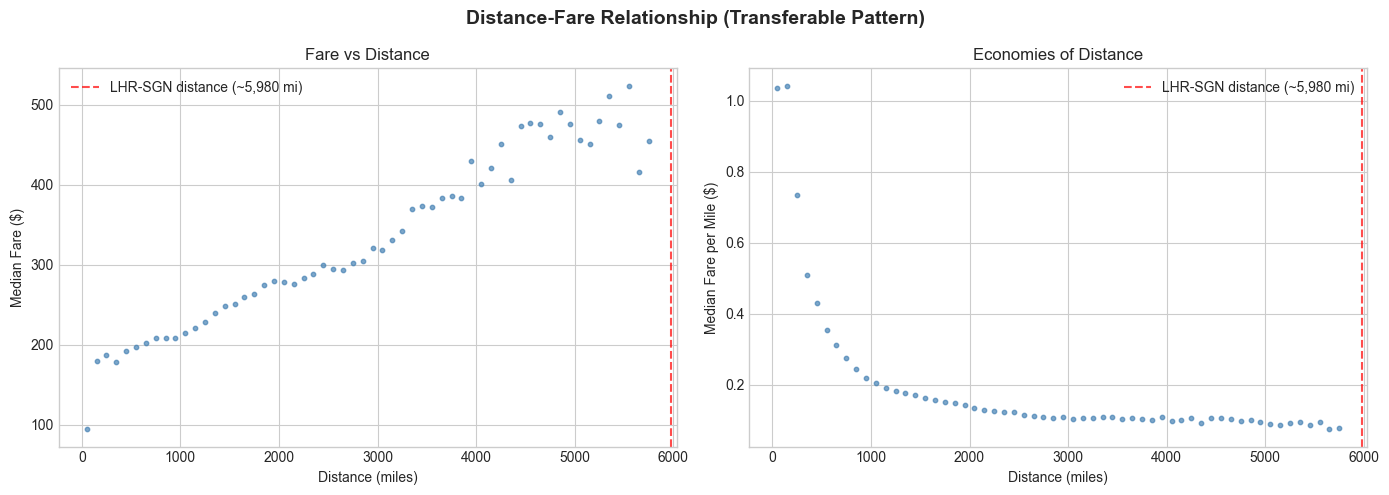

In [26]:
import numpy as np

distance_bins = np.arange(0, 6000, 100)
df["DistBin"] = pd.cut(df["MktDistance"], bins=distance_bins)

curve = (
    df.groupby("DistBin", observed=True)
    .agg(
        median_fare=("MktFare", "median"),
        median_fpm=("FarePerMile", "median"),
        count=("MktFare", "count"),
    )
    .query("count >= 50")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distance-Fare Relationship (Transferable Pattern)",
             fontsize=14, fontweight="bold")

ax = axes[0]
midpoints = [interval.mid for interval in curve.index]
ax.scatter(midpoints, curve["median_fare"], s=10, alpha=0.7, color="steelblue")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Median Fare ($)")
ax.set_title("Fare vs Distance")

# Mark LHR-SGN distance for reference
ax.axvline(5980, color="red", linestyle="--", alpha=0.7,
           label="LHR-SGN distance (~5,980 mi)")
ax.legend()

ax = axes[1]
ax.scatter(midpoints, curve["median_fpm"], s=10, alpha=0.7, color="steelblue")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Median Fare per Mile ($)")
ax.set_title("Economies of Distance")
ax.axvline(5980, color="red", linestyle="--", alpha=0.7,
           label="LHR-SGN distance (~5,980 mi)")
ax.legend()

plt.tight_layout()
plt.show()


#### Direct vs Connecting Premium by Distance Band (Transferable)

In [27]:
distance_labels = ["<500", "500-1k", "1k-2k", "2k-3k", "3k+"]
df["DistanceBand"] = pd.cut(
    df["MktDistance"],
    bins=[0, 500, 1000, 2000, 3000, 15000],
    labels=distance_labels,
)

premium = (
    df.groupby(["DistanceBand", "IsDirect"], observed=True)["FarePerMile"]
    .median()
    .unstack()
    .rename(columns={True: "Direct", False: "Connecting"})
)
premium["Premium"] = premium["Direct"] / premium["Connecting"]

print("=== DIRECT vs CONNECTING FARE-PER-MILE BY DISTANCE ===")
print(premium.round(4).to_string())
print("\nPremium > 1.0 means direct costs MORE per mile")
print("Premium < 1.0 means direct costs LESS per mile")


=== DIRECT vs CONNECTING FARE-PER-MILE BY DISTANCE ===
IsDirect      Connecting  Direct  Premium
DistanceBand                             
<500              0.5616  0.5207   0.9272
500-1k            0.3032  0.2581   0.8514
1k-2k             0.1773  0.1696   0.9565
2k-3k             0.1187  0.1274   1.0739
3k+               0.0998  0.1438   1.4416

Premium > 1.0 means direct costs MORE per mile
Premium < 1.0 means direct costs LESS per mile


In [28]:
# Check what columns exist
print(significant_routes.columns.tolist())

# Use the correct column name
y = significant_routes["mean_fpm"].values
X = significant_routes[["carriers"]].values

model = LinearRegression().fit(X, y)
print("=== COMPETITION EFFECT ON FARE-PER-MILE ===")
print(f"Each additional carrier: {model.coef_[0]:+.4f} $/mile")
print(f"R-squared:               {model.score(X, y):.3f}")

# Log-fare model
X2 = significant_routes[["carriers", "mean_distance"]].values
y2 = np.log(significant_routes["median_fare"].values)

model2 = LinearRegression().fit(X2, y2)
pct_effect = (np.exp(model2.coef_[0]) - 1) * 100
print(f"\n=== LOG-FARE MODEL ===")
print(f"Each additional carrier: {pct_effect:+.1f}% on median fare")
print(f"R-squared:               {model2.score(X2, y2):.3f}")


['records', 'median_fare', 'carriers', 'mean_distance', 'mean_fpm']
=== COMPETITION EFFECT ON FARE-PER-MILE ===
Each additional carrier: -0.0102 $/mile
R-squared:               0.030

=== LOG-FARE MODEL ===
Each additional carrier: +2.8% on median fare
R-squared:               0.368


### Nulls and Anomalies Check

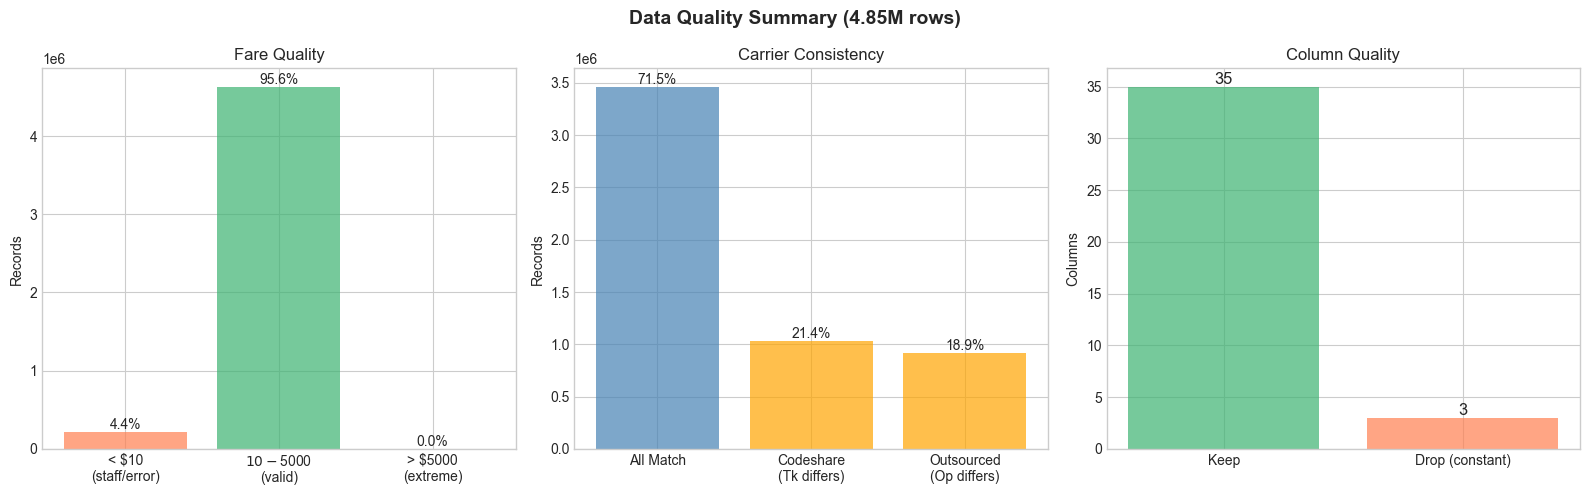

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Data Quality Summary (4.85M rows)", fontsize=14, fontweight="bold")

# 1. Fare anomalies
ax = axes[0]
labels = ["< $10\n(staff/error)", "$10-$5000\n(valid)", "> $5000\n(extreme)"]
counts = [214195, 4632928, 135]
colors = ["coral", "mediumseagreen", "coral"]
bars = ax.bar(labels, counts, color=colors, alpha=0.7)
ax.set_ylabel("Records")
ax.set_title("Fare Quality")
for bar, count in zip(bars, counts):
    pct = 100 * count / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

# 2. Carrier consistency
ax = axes[1]
labels = ["All Match", "Codeshare\n(Tk differs)", "Outsourced\n(Op differs)"]
counts = [3464201, 1035066, 913878]
colors = ["steelblue", "orange", "orange"]
bars = ax.bar(labels, counts, color=colors, alpha=0.7)
ax.set_ylabel("Records")
ax.set_title("Carrier Consistency")
for bar, count in zip(bars, counts):
    pct = 100 * count / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

# 3. Columns to drop vs keep
ax = axes[2]
drop_cols = ["BulkFare", "OriginCountry", "DestCountry"]
keep_count = len(df.columns) - len(drop_cols)
bars = ax.bar(["Keep", "Drop (constant)"], [keep_count, len(drop_cols)],
              color=["mediumseagreen", "coral"], alpha=0.7)
ax.set_ylabel("Columns")
ax.set_title("Column Quality")
for bar, count in zip(bars, [keep_count, len(drop_cols)]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(count), ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

In [30]:
# Based on null/anomaly analysis, define cleaning rules
CLEANING_RULES = {
    # Fare filtering
    "min_fare": 10.0,           # removes staff/error/FF redemptions
    "max_fare": 5000.0,         # removes extreme outliers

    # Distance filtering
    "min_distance": 50,         # removes near-zero distance anomalies
    "max_routing_ratio": 3.0,   # removes extreme detour records

    # Passenger filtering
    "min_passengers": 1,        # removes zero-passenger records

    # Column removal
    "drop_columns": [
        "BulkFare",             # constant (all zeros)
        "OriginCountry",        # constant ("US")
        "DestCountry",          # constant ("US")
        # Add any others found to be constant
    ],
}

# Calculate data retained after all filters
mask = (
    (df["MktFare"] >= CLEANING_RULES["min_fare"]) &
    (df["MktFare"] <= CLEANING_RULES["max_fare"]) &
    (df["MktDistance"] >= CLEANING_RULES["min_distance"]) &
    (df["Passengers"] >= CLEANING_RULES["min_passengers"])
)
retained = mask.sum()
print(f"\n=== DATA RETENTION AFTER CLEANING ===")
print(f"  Before: {len(df):,}")
print(f"  After:  {retained:,}")
print(f"  Retained: {100 * retained / len(df):.1f}%")



=== DATA RETENTION AFTER CLEANING ===
  Before: 4,847,258
  After:  4,632,901
  Retained: 95.6%


## Random Experiments